In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Create a dataframe titled movie_ratings that contains the ratings (G, PG, TV-G, etc) and how many of those movies exist in the dataframe.

In [25]:
disney_plus = pd.read_csv('disney_plus.csv')

In [27]:
movies = disney_plus[disney_plus.type == 'Movie']

In [28]:
movie_ratings = movies.rating.value_counts().reset_index()

In [29]:
movie_ratings

,rating,count
0,G,235
1,PG,226
2,TV-G,224
3,TV-PG,165
4,PG-13,60
5,TV-14,36
6,TV-Y7,36
7,TV-Y7-FV,6
8,TV-Y,2


2. Using the movie_ratings dataframe, create a bar chart that displays the count of the top 5 movie ratings.

    💡 Hint: Use .plot.bar() with x='rating' and y='count'. Don't forget to add a title and axis label!

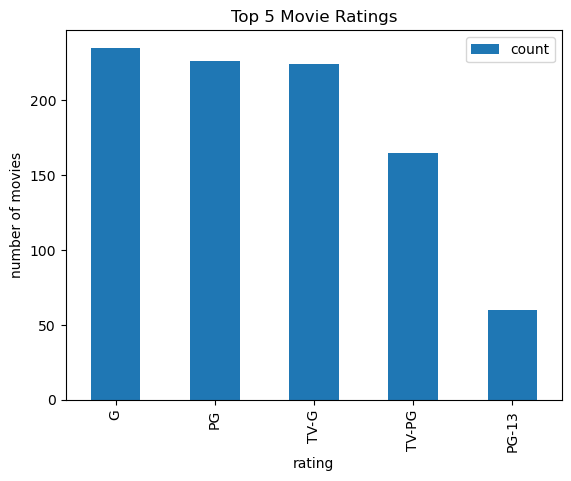

In [30]:
movie_ratings[:5].plot.bar(x='rating', y='count')
plt.title('Top 5 Movie Ratings')
plt.ylabel('number of movies')
plt.show()

3. Using movies_df, subset the data to create a new dataframe named year_duration that contains only two columns:

    release_year
    <br>duration

In [31]:
year_duration = movies[['release_year', 'duration']]

In [46]:
year_duration.duration = year_duration.duration.str[:-4].astype(int)

/tmp/ipykernel_33672/3135922262.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  year_duration.duration = year_duration.duration.str[:-4].astype(int)


In [49]:
year_duration

,release_year,duration
0,2021,88
1,2011,93
2,2014,127
6,2009,106
7,2021,22
...,...,...
1359,2001,73
1361,1978,104
1362,1986,75
1363,1963,80


4. Using your year_duration dataframe, filter for movies released between 1975 and 1984 (inclusive) and find the:

    - Minimum duration
    - Maximum duration
    - Average duration


In [50]:
year_1975_1984 = year_duration[(year_duration['release_year'] >= 1975) & (year_duration['release_year'] <= 1984)]

In [51]:
year_1975_1984.duration.min()

2

In [52]:
year_1975_1984.duration.max()

135

In [54]:
round(year_1975_1984.duration.mean())

86

5. Using the year_duration dataframe, create a scatterplot that shows movie durations over the years. Add a descriptive title to your chart.

After creating your plot, answer the following in a comment or markdown cell:

    Do you notice any correlation between release year and movie duration?


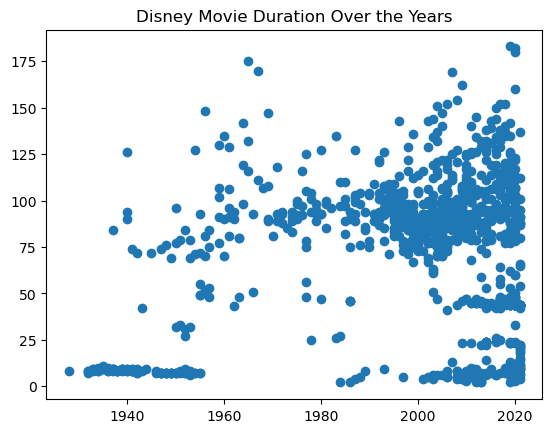

In [58]:
plt.scatter(data=year_duration, x='release_year', y='duration')
plt.title('Disney Movie Duration Over the Years')
plt.show()

Movie duration seems to increase slightly as the release year increases. There is also a larger variety of durations in later years.

6. Find the actual correlation value between release_year and duration.

    💡 Hint: Use .corr() on the year_duration dataframe.

Answer the following in a comment or markdown cell:

    Based on the correlation value, is there a meaningful correlation between release year and duration?


In [59]:
year_duration.corr()

,release_year,duration
release_year,1.000000,0.241268
duration,0.241268,1.000000


There is a somewhat positive correlation between release year and duration. It not especially strong, but still noticeable.

7. Using movies_df, find which year had the most G-rated movie releases.

    🎯 Challenge: Can you accomplish this in a single line of code?

In [65]:
movies[movies.rating == 'G'].groupby('release_year')['release_year'].count().sort_values(ascending=False).head(1)

release_year
2003    12
Name: release_year, dtype: int64

8. <br>
    1. Find which year had the most total movie releases.<br>
    2. Create a new dataframe containing only movies from that year.<br>
    3. Convert the duration column to integers.<br>
    4. Use the IQR method to determine the upper and lower cutoffs for outliers.<br>
    5. Calculate what percentage of movies from that year had durations that were statistical outliers.<br>
   💡 Hint: Outlier cutoffs are defined as:

    - Lower cutoff: Q1 − (1.5 × IQR)
    - Upper cutoff: Q3 + (1.5 × IQR)


In [66]:
movies.groupby('release_year')['release_year'].count().sort_values(ascending=False).head(1)

release_year
2020    72
Name: release_year, dtype: int64

In [68]:
movies_2020 = movies[movies.release_year == 2020]

In [70]:
movies_2020.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
10,s11,Movie,Jade Eyed Leopard,NaN,Jeremy Irons,NaN,"September 17, 2021",2020,TV-PG,44 min,"Animals & Nature, Documentary","Jade Eyed Leopard follows a leopard, Toto, thr..."
65,s66,Movie,Shark vs. Surfer,Phil Stebbing,Billy Lloyd,NaN,"July 23, 2021",2020,TV-14,44 min,"Animals & Nature, Documentary",Shark vs. Surfer visits shark-infested surf sp...
66,s67,Movie,Shark vs. Whale,NaN,Ted Stewart,NaN,"July 23, 2021",2020,TV-PG,44 min,"Animals & Nature, Documentary",Marine biologist Ryan Johnson discovers rare b...
69,s70,Movie,What the Shark?,NaN,Robert Davi,NaN,"July 23, 2021",2020,TV-PG,44 min,"Animals & Nature, Documentary",What the Shark? dives deep into the environmen...
75,s76,Movie,Most Wanted Sharks,NaN,NaN,NaN,"July 16, 2021",2020,TV-PG,44 min,"Animals & Nature, Documentary","In Most Wanted Sharks, Jeremiah Sullivan dives..."


In [71]:
movies_2020.duration = movies_2020.duration.str[:-4].astype(int)

/tmp/ipykernel_33672/4122272581.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_2020.duration = movies_2020.duration.str[:-4].astype(int)


In [73]:
movies_2020.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72 entries, 10 to 571
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       72 non-null     object
 1   type          72 non-null     object
 2   title         72 non-null     object
 3   director      52 non-null     object
 4   cast          59 non-null     object
 5   country       59 non-null     object
 6   date_added    72 non-null     object
 7   release_year  72 non-null     int64 
 8   rating        72 non-null     object
 9   duration      72 non-null     int64 
 10  listed_in     72 non-null     object
 11  description   72 non-null     object
dtypes: int64(2), object(10)
memory usage: 7.3+ KB


In [74]:
duration_2020_q1 = movies_2020.duration.quantile(0.25)

In [76]:
duration_2020_q3 = movies_2020.duration.quantile(0.75)

In [78]:
duration_2020_iqr = duration_2020_q3 - duration_2020_q1

In [80]:
duration_2020_upper = duration_2020_q3 + (1.5 * duration_2020_iqr)

In [84]:
print(duration_2020_upper)

171.5


In [82]:
duration_2020_lower = duration_2020_q1 - (1.5 * duration_2020_iqr)

In [85]:
print(duration_2020_lower)

-32.5


In [88]:
outliers_2020 = movies_2020[(movies_2020.duration > duration_2020_upper) | (movies_2020.duration < duration_2020_lower)]

In [95]:
print(str(round((len(outliers_2020) / len(movies_2020)) * 100, 2)) + '%')

2.78%


9. Add a new column called length_category to movies_df that categorizes each movie as one of the following:
<br>Category 	Duration
<br>short 	30 minutes or less
<br>average 	Between 31–120 minutes
<br>long 	More than 120 minutes

Bonus: Once the column is created, create a pie chart showing the distribution of movie length categories.

In [97]:
movies.loc[movies.duration.str[:-4].astype(int) <= 30, 'length_category'] = 'short'

/tmp/ipykernel_33672/2979728010.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies.loc[movies.duration.str[:-4].astype(int) <= 30, 'length_category'] = 'short'


In [99]:
movies.loc[movies.duration.str[:-4].astype(int) > 120, 'length_category'] = 'long'

In [102]:
movies['length_category'] = movies['length_category'].fillna('average')

/tmp/ipykernel_33672/3898843301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['length_category'] = movies['length_category'].fillna('average')


In [116]:
movies['length_category'].value_counts()

length_category
average    698
short      205
long        88
Name: count, dtype: int64

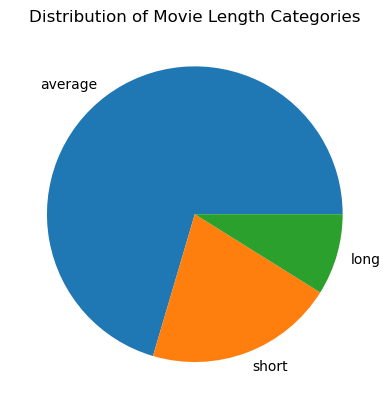

In [117]:
plt.pie(movies['length_category'].value_counts(), labels=movies['length_category'].value_counts().index)
plt.title('Distribution of Movie Length Categories')
plt.show()

10. <br>
    1. Create a new column called gap that calculates the difference between the year a movie was added to Disney+ and its original release_year.<br>
    2. Find the movie with the greatest gap. <br>
    3. Find the average gap across all movies. 

In [123]:
movies.date_added = pd.to_datetime(movies.date_added)

/tmp/ipykernel_33672/427518949.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies.date_added = pd.to_datetime(movies.date_added)


In [129]:
movies['gap'] = movies.date_added.dt.year - movies.release_year

/tmp/ipykernel_33672/2889849683.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['gap'] = movies.date_added.dt.year - movies.release_year


In [132]:
movies.sort_values(by='gap', ascending=False).head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,length_category,gap
1146,s1147,Movie,Steamboat Willie,"Walt Disney, Ub Iwerks",Walt Disney,United States,2019-11-12,1928,TV-Y7,8 min,"Animation, Family, Kids",Watch Mickey Mouse's classic cartoon debut. Se...,short,91


In [135]:
print(round(movies.gap.mean()))

21
